In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
# from sklearn.preprocessing import StandardScaler
from util import concat_hrf, group_by_dict_fields
import os
import globals as gl
from pcm_models import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
from statsmodels.stats.anova import AnovaRM
import pickle
import pingouin as pg
from matplotlib import colormaps as cm
from vis import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, add_significance_bars, set_spines_and_ticks_width, add_noise_ceiling, make_yref, load_border_vertices_xml
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib.lines import Line2D
import os
import globals as gl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nibabel as nb
import numpy as np
import nitools as nt
from matplotlib.colors import LinearSegmentedColormap
import pyvista as pv
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_1samp

import nitools as nt

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [3]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

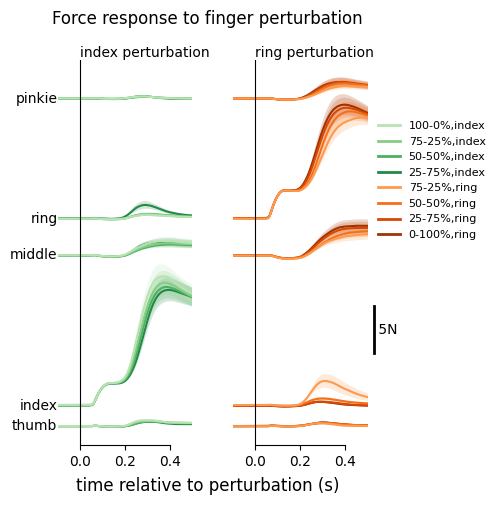

In [6]:
from vis import plot_force_response

experiment = 'smp2'
npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_force_response(fig, axs, force, descr)
plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue 20.7316 3.0000 39.0000 0.0000

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  7.4148 3.0000 39.0000 0.0005



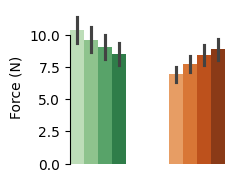

In [12]:
experiment = 'smp2'

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir,
                                f'{experiment}_force_single_trial.tsv'), sep='\t',)
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))

sns.barplot(dat[dat['stimFinger']=='index'], x='cue', y='index1', ax=axs[0], errorbar='se',
            width=1, palette=list(gl.colour_mapping.values())[5:9], order=list(gl.regressor_mapping)[0:4])
sns.barplot(dat[dat['stimFinger']=='ring'], x='cue', y='ring1', ax=axs[1], errorbar='se',
            width=1,  palette=list(gl.colour_mapping.values())[9:13], order=list(gl.regressor_mapping)[1:5])

anova_index = AnovaRM(data=dat[dat['stimFinger']=='index'], depvar='index1', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

for ax in axs:
    ax.set_xticks([])
    ax.spines[['bottom', 'right', 'top']].set_visible(False)
    ax.set_xlabel('')

axs[0].spines[['left']].set_bounds(0, 10)
axs[1].spines[['left']].set_visible(False)
axs[1].tick_params(width=0)
axs[0].set_ylabel('Force (N)')

plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  3.4133 4.0000 52.0000 0.0149

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.0417 4.0000 52.0000 0.0005



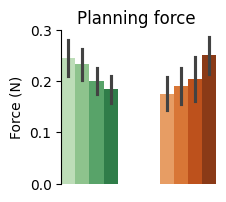

In [14]:
experiment = 'smp2'

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir,
                                f'{experiment}_force_single_trial.tsv'), sep='\t',)
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))

sns.barplot(dat[dat['stimFinger']=='nogo'], x='cue', y='index0', ax=axs[0], errorbar='se',
            width=1, palette=list(gl.colour_mapping.values())[5:9], order=list(gl.regressor_mapping)[0:4])
sns.barplot(dat[dat['stimFinger']=='nogo'], x='cue', y='ring0', ax=axs[1], errorbar='se',
            width=1,  palette=list(gl.colour_mapping.values())[9:13], order=list(gl.regressor_mapping)[1:5])

anova_index = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='index0', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='ring0', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

for ax in axs:
    ax.set_xticks([])
    ax.spines[['bottom', 'right', 'top']].set_visible(False)
    ax.set_xlabel('')

axs[0].spines[['left']].set_bounds(0, .3)
axs[1].spines[['left']].set_visible(False)
axs[1].tick_params(width=0)
axs[0].set_ylabel('Force (N)')

fig.suptitle('Planning force')

plt.show()

rmANOVA index
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond 17.8907 1.0000 13.0000 0.0010

rmANOVA ring
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond  6.7472 1.0000 13.0000 0.0221



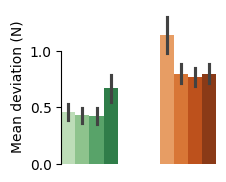

In [16]:
experiment = 'smp2'

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir,
                                f'{experiment}_force_single_trial.tsv'), sep='\t',)
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()
dat['correspond'] = 'high'
mask_low = ((dat['cue'] == '75-25%') & (dat['stimFinger'] == 'ring')) | ((dat['cue'] == '25-75%') & (dat['stimFinger'] == 'index'))
dat.loc[mask_low, 'correspond'] = 'low'
dat = dat[dat['GoNogo'] == 'go']

dat_plot = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo','correspond']).mean(numeric_only=True).reset_index()
dat_stat = dat.groupby(['sn', 'stimFinger', 'GoNogo','correspond']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))

sns.barplot(dat_plot[dat_plot['stimFinger']=='index'], x='cue', y='MD', ax=axs[0], errorbar='se', width=1, palette=list(gl.colour_mapping.values())[5:9], order=list(gl.regressor_mapping)[0:4])
sns.barplot(dat_plot[dat_plot['stimFinger']=='ring'], x='cue', y='MD', ax=axs[1], errorbar='se', width=1,  palette=list(gl.colour_mapping.values())[9:13], order=list(gl.regressor_mapping)[1:5])

anova_index = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='index'], depvar='index1', subject='sn', within=['correspond'])
anova_ring = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['correspond'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

for ax in axs:
    ax.set_xticks([])
    ax.spines[['bottom', 'right', 'top']].set_visible(False)
    ax.set_xlabel('')

axs[0].spines[['left']].set_bounds(0, 1)
axs[1].spines[['left']].set_visible(False)
axs[1].tick_params(width=0)
axs[0].set_ylabel('Mean deviation (N)')

plt.show()

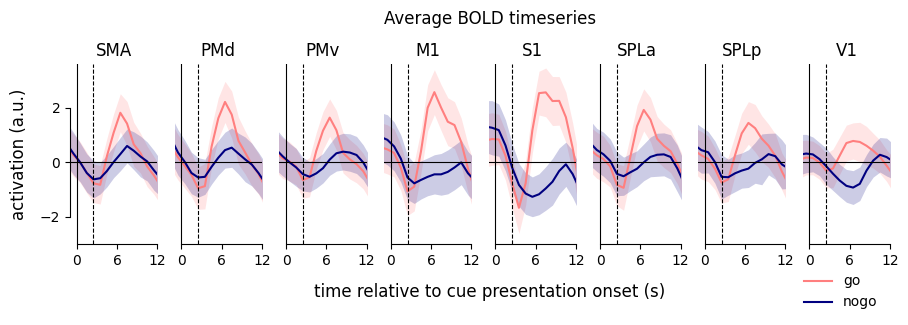

In [21]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 12
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]

Ts = [os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', 'T.mat') for sn in snS]

T = concat_hrf(Ts)
T_avg = group_by_dict_fields(T, ['GoNogo', 'SN'], ['y_adj'])

tAx = np.linspace(-10, 20, T['y_adj'].shape[-1]) + .5

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 3))
for r in range(len(rois)):

    ax = axs[r]

    hem = T['hem']==Hem
    roi = T['name']==rois[r]
    go = T['GoNogo']=='go'

    y_adj_go = np.nanmean(T['y_adj'][go & roi & hem], axis=0)
    y_adj_nogo = np.nanmean(T['y_adj'][~go & roi & hem], axis=0)

    y_adj_go_err = np.nanstd(T['y_adj'][go & roi & hem], axis=0) / np.sqrt(len(snS))
    y_adj_nogo_err = np.nanstd(T['y_adj'][~go & roi & hem], axis=0) / np.sqrt(len(snS))

    ax.plot(tAx, y_adj_go, color='#FF7F7F', label='go', ls='-')
    ax.plot(tAx,y_adj_nogo, color='#000080', label='nogo', ls='-')
    ax.fill_between(tAx,y_adj_go - y_adj_go_err, y_adj_go + y_adj_go_err,
                           color='#FF7F7F', alpha=.2, lw=0)
    ax.fill_between(tAx,y_adj_nogo - y_adj_nogo_err, y_adj_nogo + y_adj_nogo_err,
                           color='#000080', alpha=.2, lw=0)

    ax.axvline(0, color='k', ls='-', lw=.8)
    ax.axvline(2.5, color='k', ls='--', lw=.8)
    ax.axhline(0, color='k', ls='-', lw=.8)

    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 12)
    ax.set_xticks([0, 6, 12])
    if r==0:
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_bounds(-2, 2)
    else:
        ax.tick_params('y', width=0)

    ax.set_xlim((-1, 12))
    ax.set_ylim((-3, 3.6))

    ax.set_title(rois[r])

ax.legend(frameon=False, bbox_to_anchor=(1, -.1), loc='upper right', )

fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to cue presentation onset (s)')
fig.suptitle(f'Average BOLD timeseries')

fig.subplots_adjust(bottom=.2, top=.8, left=.08)

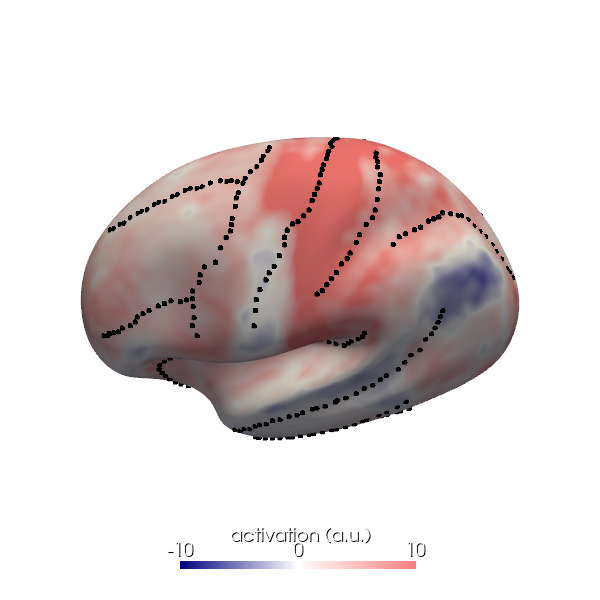

In [29]:
experiment = 'smp2'
glm = 12
dtype = 'con'
H = 'L'

# Define colors with non-uniform positions to steepen the extremities
colors = [
    (0.0, '#000080'),   # Navy
    (0.5, 'white'),    # Symmetric midpoint
    (1.0, '#FF7F7F')    # Saturated peach
]

# Create custom colormap with steeper outer transitions
cmap = LinearSegmentedColormap.from_list('steep_navy_peach', colors)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
column_names = cifti.header.get_axis(0).name
giftis = nt.split_cifti_to_giftis(cifti, type='func', column_names=column_names)

p = pv.Plotter(window_size=(600, 600))

# for h, H in enumerate(Hem):

surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
coords = surf.darrays[0].data
faces = surf.darrays[1].data.astype(np.uint32)  # pyvista requires uint32
data = nt.get_gifti_data_matrix(giftis[0])[:, 1]
faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
if H=='L':
    sulc = sulc[:len(data)]
else:
    sulc = sulc[len(data):]

# Now create the mesh
mesh = pv.PolyData(coords, faces)
mesh.point_data["overlay"] = data

mesh.point_data["sulc"] = sulc

border_verts = load_border_vertices_xml(f'/home/UWO/memanue5/Documents/GitHub/surfAnalysisPy/standard_mesh/fs_{H}/fs_LR.32k.{H}.border')
border = coords[border_verts]

p.add_mesh(mesh, scalars="sulc", cmap="Greys", clim=[-2, 2], lighting=True, show_scalar_bar=False)
p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-10, 10], lighting=True, show_scalar_bar=False)
p.add_scalar_bar(title="activation (a.u.)",
             n_labels=3,                 # Show fewer ticks
             vertical=False,            # Horizontal layout
             color='w',
             shadow=True,
             fmt="%.0f",
             position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
             position_y=0.05, # Lower position (closer to bottom of figure)
             width=0.4,       # Proportion of figure width
             height=0.04)
p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background("white")
p.view_vector((-1, 0, 1))        # start from a good view
 # dorsal view

p.show()

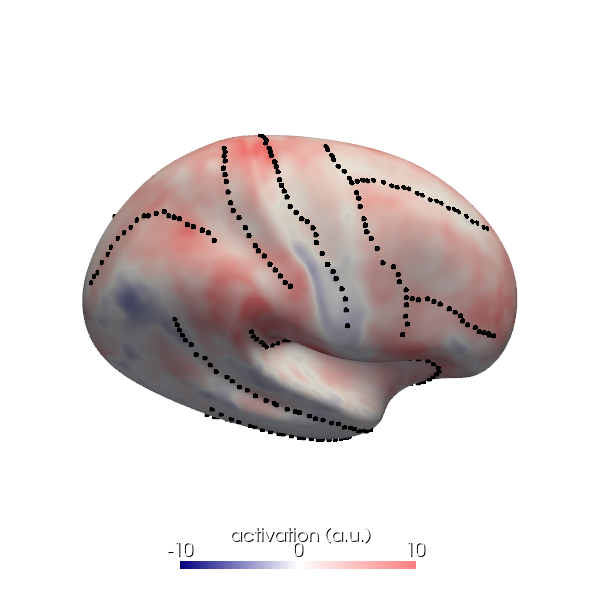

In [30]:
experiment = 'smp2'
glm = 12
dtype = 'con'
H = 'R'

# Define colors with non-uniform positions to steepen the extremities
colors = [
    (0.0, '#000080'),   # Navy
    (0.5, 'white'),    # Symmetric midpoint
    (1.0, '#FF7F7F')    # Saturated peach
]

# Create custom colormap with steeper outer transitions
cmap = LinearSegmentedColormap.from_list('steep_navy_peach', colors)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
column_names = cifti.header.get_axis(0).name
giftis = nt.split_cifti_to_giftis(cifti, type='func', column_names=column_names)

p = pv.Plotter(window_size=(600, 600))

# for h, H in enumerate(Hem):

surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
coords = surf.darrays[0].data
faces = surf.darrays[1].data.astype(np.uint32)  # pyvista requires uint32
data = nt.get_gifti_data_matrix(giftis[1])[:, 1]
faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
if H=='L':
    sulc = sulc[:len(data)]
else:
    sulc = sulc[len(data):]

# Now create the mesh
mesh = pv.PolyData(coords, faces)
mesh.point_data["overlay"] = data

mesh.point_data["sulc"] = sulc

border_verts = load_border_vertices_xml(f'/home/UWO/memanue5/Documents/GitHub/surfAnalysisPy/standard_mesh/fs_{H}/fs_LR.32k.{H}.border')
border = coords[border_verts]

p.add_mesh(mesh, scalars="sulc", cmap="Greys", clim=[-2, 2], lighting=True, show_scalar_bar=False)
p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-10, 10], lighting=True, show_scalar_bar=False)
p.add_scalar_bar(title="activation (a.u.)",
             n_labels=3,                 # Show fewer ticks
             vertical=False,            # Horizontal layout
             color='w',
             shadow=True,
             fmt="%.0f",
             position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
             position_y=0.05, # Lower position (closer to bottom of figure)
             width=0.4,       # Proportion of figure width
             height=0.04)
p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background("white")
p.view_vector((1, 0, 1))        # start from a good view
 # dorsal view

p.show()

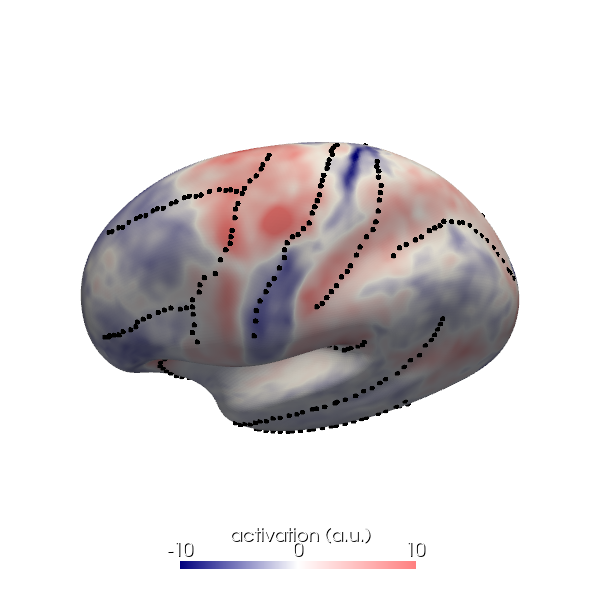

In [34]:
experiment = 'smp2'
glm = 12
dtype = 'con'
H = 'L'

# Define colors with non-uniform positions to steepen the extremities
colors = [
    (0.0, '#000080'),   # Navy
    (0.5, 'white'),    # Symmetric midpoint
    (1.0, '#FF7F7F')    # Saturated peach
]

# Create custom colormap with steeper outer transitions
cmap = LinearSegmentedColormap.from_list('steep_navy_peach', colors)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
column_names = cifti.header.get_axis(0).name
giftis = nt.split_cifti_to_giftis(cifti, type='func', column_names=column_names)

p = pv.Plotter(window_size=(600, 600))

# for h, H in enumerate(Hem):

surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
coords = surf.darrays[0].data
faces = surf.darrays[1].data.astype(np.uint32)  # pyvista requires uint32
data = nt.get_gifti_data_matrix(giftis[0])[:, 0]
faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
if H=='L':
    sulc = sulc[:len(data)]
else:
    sulc = sulc[len(data):]

# Now create the mesh
mesh = pv.PolyData(coords, faces)
mesh.point_data["overlay"] = data

mesh.point_data["sulc"] = sulc

border_verts = load_border_vertices_xml(f'/home/UWO/memanue5/Documents/GitHub/surfAnalysisPy/standard_mesh/fs_{H}/fs_LR.32k.{H}.border')
border = coords[border_verts]

p.add_mesh(mesh, scalars="sulc", cmap="Greys", clim=[-2, 2], lighting=True, show_scalar_bar=False)
p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-10, 10], lighting=True, show_scalar_bar=False)
p.add_scalar_bar(title="activation (a.u.)",
             n_labels=3,                 # Show fewer ticks
             vertical=False,            # Horizontal layout
             color='w',
             shadow=True,
             fmt="%.0f",
             position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
             position_y=0.05, # Lower position (closer to bottom of figure)
             width=0.4,       # Proportion of figure width
             height=0.04)
p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background("white")
p.view_vector((-1, 0, 1))        # start from a good view
 # dorsal view

p.show()

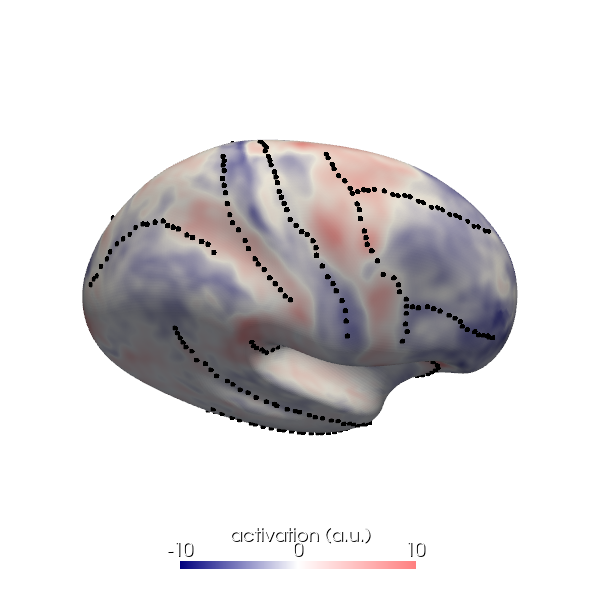

In [33]:
experiment = 'smp2'
glm = 12
dtype = 'con'
H = 'R'

# Define colors with non-uniform positions to steepen the extremities
colors = [
    (0.0, '#000080'),   # Navy
    (0.5, 'white'),    # Symmetric midpoint
    (1.0, '#FF7F7F')    # Saturated peach
]

# Create custom colormap with steeper outer transitions
cmap = LinearSegmentedColormap.from_list('steep_navy_peach', colors)

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
column_names = cifti.header.get_axis(0).name
giftis = nt.split_cifti_to_giftis(cifti, type='func', column_names=column_names)

p = pv.Plotter(window_size=(600, 600))

# for h, H in enumerate(Hem):

surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
coords = surf.darrays[0].data
faces = surf.darrays[1].data.astype(np.uint32)  # pyvista requires uint32
data = nt.get_gifti_data_matrix(giftis[1])[:, 0]
faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
if H=='L':
    sulc = sulc[:len(data)]
else:
    sulc = sulc[len(data):]

# Now create the mesh
mesh = pv.PolyData(coords, faces)
mesh.point_data["overlay"] = data

mesh.point_data["sulc"] = sulc

border_verts = load_border_vertices_xml(f'/home/UWO/memanue5/Documents/GitHub/surfAnalysisPy/standard_mesh/fs_{H}/fs_LR.32k.{H}.border')
border = coords[border_verts]

p.add_mesh(mesh, scalars="sulc", cmap="Greys", clim=[-2, 2], lighting=True, show_scalar_bar=False)
p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-10, 10], lighting=True, show_scalar_bar=False)
p.add_scalar_bar(title="activation (a.u.)",
             n_labels=3,                 # Show fewer ticks
             vertical=False,            # Horizontal layout
             color='w',
             shadow=True,
             fmt="%.0f",
             position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
             position_y=0.05, # Lower position (closer to bottom of figure)
             width=0.4,       # Proportion of figure width
             height=0.04)
p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background("white")
p.view_vector((1, 0, 1))        # start from a good view
 # dorsal view

p.show()

ROI: SMA
planning vs. execution: TtestResult(statistic=np.float64(0.7975754191177965), pvalue=np.float64(0.4394428399104966), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(3.1080486565483554), pvalue=np.float64(0.008316910783281678), df=np.int64(13))
execution vs. 0: TtestResult(statistic=np.float64(3.5174613946572375), pvalue=np.float64(0.0037851880565325647), df=np.int64(13))
ROI: PMd
planning vs. execution: TtestResult(statistic=np.float64(0.4767158813953799), pvalue=np.float64(0.6414779159758389), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(3.964293111737123), pvalue=np.float64(0.0016173310555956959), df=np.int64(13))
execution vs. 0: TtestResult(statistic=np.float64(4.372142232273341), pvalue=np.float64(0.0007554753037689774), df=np.int64(13))
ROI: PMv
planning vs. execution: TtestResult(statistic=np.float64(0.6463225238182332), pvalue=np.float64(0.529316042160221), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(2.623200

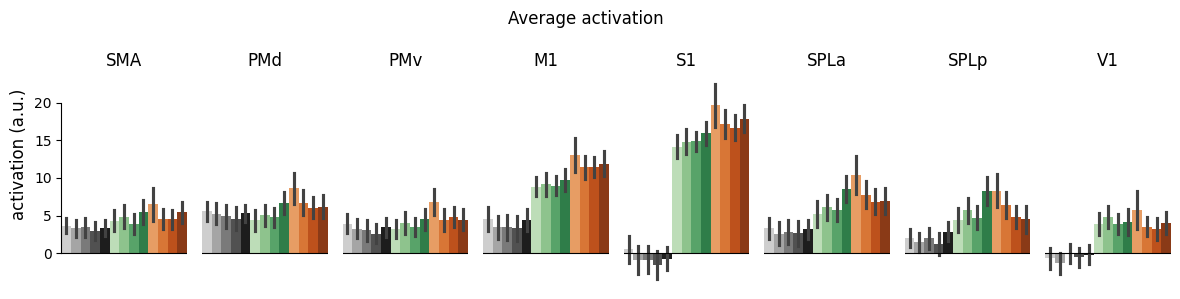

In [55]:
glm = 12
experiment = 'smp2'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
H = 'L'
conditions = list(gl.regressor_mapping.keys())[0:13]

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}','ROI.con.avg.tsv'), sep='\t')
df_con['sn'] = df_con['sn'].astype(str)
df_con = df_con[df_con['condition'].isin(conditions)]
df_con['epoch'] = 'planning'
mask = df_con['condition'].str.contains('index') | df_con['condition'].str.contains('ring')
df_con.loc[mask, 'epoch'] = 'execution'

df_con_stat = df_con.groupby(['sn', 'roi', 'Hem', 'epoch']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(12, 3))

for r, roi in enumerate(rois):

    ax = axs[r]

    sns.barplot(df_con[(df_con['roi'] == roi) & (df_con['Hem'] == H)],
                ax=ax,
                y='con',
                x='condition',
                order=conditions,
                palette=[gl.colour_mapping[cond] for cond in conditions],
                # showfliers=False,
                errorbar='se',
                width=1,
                legend=False
                )

    ax.axhline(0, ls='-', color='k', lw=.8)
    ax.set_title(roi)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelbottom=False, width=0)

    ax.spines[['left', 'top', 'right', 'bottom']].set_visible(False)
    if r==0:
        ax.spines[['left',]].set_visible(True)
        ax.spines[['left',]].set_bounds(0, 20)
    else:
        ax.tick_params(axis='y',width=0)

    plan = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'planning')]['con']
    exec = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'execution')]['con']

    print(f'ROI: {roi}')
    print(f'planning vs. execution: {ttest_rel(exec, plan)}')
    print(f'planning vs. 0: {ttest_1samp(plan, 0)}')
    print(f'execution vs. 0: {ttest_1samp(exec, 0)}')

fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activation')
fig.tight_layout()

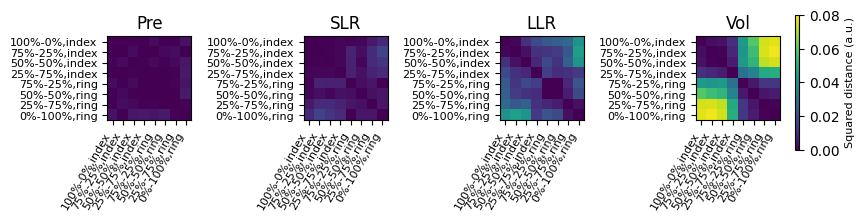

In [5]:
experiment = 'smp0'

vmin, vmax = -0., .08

epochs = ['Pre', 'SLR', 'LLR', 'Vol']

fig, axs = plt.subplots(1, 4, figsize=(8, 4))

for e, epoch in enumerate(epochs):
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy'))
    D = pcm.G_to_dist(G_obs.mean(axis=(0,)))

    ax = axs[e]

    cax = ax.imshow(D, vmin=vmin, vmax=vmax)
    ax.set_title(f'{epoch}')

    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)
    ax.set_xticks(ax.get_yticks())
    ax.set_xticklabels(ax.get_yticklabels(), fontsize=8, rotation=60, ha='right')

# Colorbar for imshow (top row)
bbox = axs[0].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('Squared distance (a.u.)', fontsize=8)

fig.tight_layout()

plt.show()

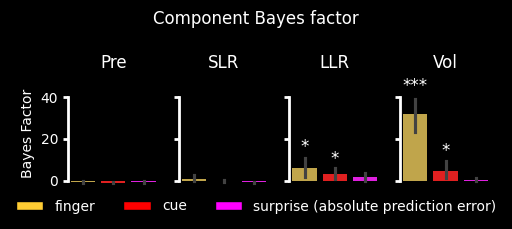

In [116]:
experiment = 'smp0'

components = ['finger', 'cue', 'surprise']

epochs = ['Pre', 'SLR', 'LLR', 'Vol']

M = make_execution_models()
M, _ = find_model(M, 'component')
G = M.Gc
MF = pcm.model.ModelFamily(G, comp_names=components, basecomponents=np.eye(8)[None,:,:])

fig, axs = plt.subplots(1, len(epochs), figsize=(5, 2), sharey=True, constrained_layout=True)

for r, epoch in enumerate(epochs):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.emg.{epoch}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf',palette=['#D4AF37', 'red', 'magenta'])

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0, alternative='greater')

        mean = vals.mean()
        sem = vals.std(ddof=1) / (n**0.5)
        ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
        bar_height = mean + ci

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].set_title(epoch)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(components, rotation=60, ha='right')
    # axs[r].hlines(0, 0, 4, color='w', lw=0.8)
    axs[r].spines[['top', 'right', 'bottom']].set_visible(False)
    axs[r].spines[['left', ]].set_bounds(0, 40)
    axs[r].spines[['left', ]].set_linewidth(2)
    # axs[r].set_yticks([-.5, 0, 1, 2])
    axs[r].set_ylim([-5, 50])
    axs[r].spines[['bottom',]].set_bounds(0, 5)
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    axs[r].tick_params(width=2)

# Define legend handles
legend_handles = [
    Patch(facecolor='#FFCC33', edgecolor='black', label='finger'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (absolute prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=6,
           fontsize=10)

fig.suptitle('Component Bayes factor')

fig.tight_layout()

plt.show()

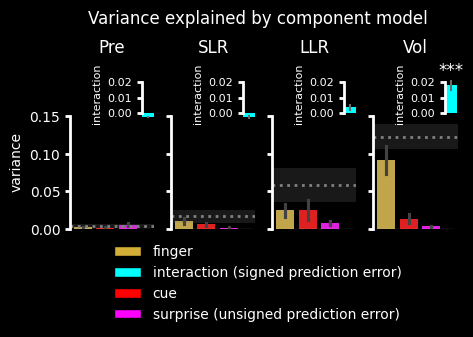

In [109]:
experiment = 'smp0'

epochs = ['Pre', 'SLR', 'LLR', 'Vol']

components = np.array(['finger', 'cue', 'surprise'])

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.emg.pkl'), 'component')
n_param_c = Mc.n_param

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.emg.pkl'), 'feature')
n_param_f = Mf.n_param

fig, axs = plt.subplots(1, len(epochs), figsize=(5, 3), sharey=True, )

inset_axs = []

for e, epoch in enumerate(epochs):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.p'), "rb")
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])

    ax = axs[e]
    params = pickle.load(f)

    # variance explained
    params_c = params[idxc]
    theta_c = params_c[:n_param_c]
    var_expl = np.exp(theta_c)

    # interaction
    params_f = params[idxf]
    theta_f = params_f[:n_param_f]
    interaction = theta_f[1, :] * theta_f[2, :]

    # main axes
    sns.barplot(data=var_expl.T, ax=ax, palette=['#D4AF37', 'red', 'magenta'], errorbar='se')
    ax.set_title(epoch, pad=10)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(components, rotation=60, ha='right')
    ax.hlines(0, 0, 3, color='w', lw=0.8)
    ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
    ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.spines[['left', ]].set_bounds(0, .15)
    ax.spines[['left', ]].set_linewidth(2)
    # ax.set_yticks([-.5, 0, 1, 2])
    ax.set_ylim((0, .18))
    ax.spines[['bottom',]].set_bounds(0, 4)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.set_ylabel('variance')
    ax.tick_params(width=2)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    # inset for interaction
    inset_ax = ax.inset_axes([.85, .8, .15, .4], transform=ax.transAxes)
    interaction = theta_f[1,:] * theta_f[2,:]
    inset_ax.bar(0, interaction.mean(), width=.5, facecolor='cyan', yerr=interaction.std() / np.sqrt(len(interaction)), ecolor='dimgrey')
    inset_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    inset_ax.spines[['left', ]].set_linewidth(2)
    inset_ax.set_yticks((0, .01, .02))
    inset_ax.spines[['left', ]].set_bounds(0, .02)
    inset_ax.set_ylabel('interaction', fontsize=8)
    inset_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    inset_ax.tick_params(axis='y', width=2, labelsize=8)
    inset_ax.set_ylim(-.005, .03)

    # t-test against zero for interaction
    _, p_val_1samp = ttest_1samp(interaction, 0, alternative='greater')

    n = len(interaction)
    mean = np.abs(interaction.mean())
    sem = interaction.std() / np.sqrt(len(interaction))
    bar_height = np.sign(interaction.mean()) * (mean + sem) * 1

    if p_val_1samp < 0.001:
        stars = '***'
    elif p_val_1samp < 0.01:
        stars = '**'
    elif p_val_1samp < 0.05:
        stars = '*'
    else:
        stars = None

    if stars:
        inset_ax.text(0, bar_height, stars, ha='center', va='bottom', fontsize=12)

    inset_axs.append(inset_ax)

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction (signed prediction error)'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (unsigned prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=1,
           fontsize=10)

fig.subplots_adjust(bottom=.25, top=.7)

fig.suptitle('Variance explained by component model')

plt.show()

ROI:SMA; TtestResult(statistic=np.float64(3.115397692164535), pvalue=np.float64(0.008200080808166777), df=np.int64(13))
ROI:PMd; TtestResult(statistic=np.float64(3.450583475711001), pvalue=np.float64(0.004303296695170072), df=np.int64(13))
ROI:PMv; TtestResult(statistic=np.float64(4.124684342376351), pvalue=np.float64(0.0011965439939308964), df=np.int64(13))
ROI:M1; TtestResult(statistic=np.float64(2.816644630474698), pvalue=np.float64(0.014558304517351926), df=np.int64(13))
ROI:S1; TtestResult(statistic=np.float64(4.319123346954082), pvalue=np.float64(0.0008332360088043044), df=np.int64(13))
ROI:SPLa; TtestResult(statistic=np.float64(3.338520439903299), pvalue=np.float64(0.005337234506141392), df=np.int64(13))
ROI:SPLp; TtestResult(statistic=np.float64(3.835943635036753), pvalue=np.float64(0.002061758198681599), df=np.int64(13))
ROI:V1; TtestResult(statistic=np.float64(3.8997134189687994), pvalue=np.float64(0.0018271611128649235), df=np.int64(13))


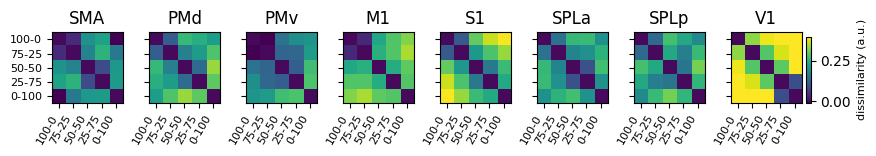

In [44]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

vmin, vmax = -.01, .4

fig, axs = plt.subplots(1, len(rois), figsize=(8, 4),sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))  #.mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs.mean(axis=0))
    D_obs_sqrt = np.sign(D_obs) * np.sqrt(np.abs(D_obs))

    D = np.zeros(G_obs.shape[0])
    for g, G in enumerate(G_obs):
        mask = np.tri(G.shape[0], k=-1, dtype=bool)
        D[g] = pcm.G_to_dist(G)[mask].mean()

    print(f'ROI:{roi}; {ttest_1samp(D, 0)}')

    # Top row: imshow
    im_ax = axs[r]
    cax = im_ax.imshow(D_obs_sqrt, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(5))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    # if r==0:
    im_ax.set_yticks(np.arange(5))
    im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)

bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('dissimilarity (a.u.)', fontsize=8)

plt.show()

ROI: SMA, TtestResult(statistic=np.float64(3.240273588483073), pvalue=np.float64(0.0032239106465261082), df=np.int64(13))
ROI: PMd, TtestResult(statistic=np.float64(2.4039533528025934), pvalue=np.float64(0.015924210890904487), df=np.int64(13))
ROI: PMv, TtestResult(statistic=np.float64(2.57868582929597), pvalue=np.float64(0.011456804556234788), df=np.int64(13))
ROI: M1, TtestResult(statistic=np.float64(2.090422465624917), pvalue=np.float64(0.028395344311236668), df=np.int64(13))
ROI: S1, TtestResult(statistic=np.float64(2.899377544260103), pvalue=np.float64(0.006211375465103722), df=np.int64(13))
ROI: SPLa, TtestResult(statistic=np.float64(1.847949784015954), pvalue=np.float64(0.04374131724691666), df=np.int64(13))
ROI: SPLp, TtestResult(statistic=np.float64(3.0484942502044743), pvalue=np.float64(0.004663481010110837), df=np.int64(13))
ROI: V1, TtestResult(statistic=np.float64(2.963735848445156), pvalue=np.float64(0.005489104556568168), df=np.int64(13))


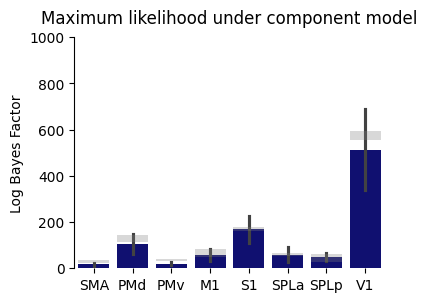

In [46]:
# Settings
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

# Initialize container
LL = {
    'roi': [],
    'noise_upper': [],
    'noise_lower': [],
    'baseline': [],
    'likelihood': [],
}

# Load and organize data
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{H}.{roi}.p'))

    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

# Convert to DataFrame
LL = pd.DataFrame(LL)

# Baseline subtraction
baseline = LL['baseline'].values
LL[['noise_upper', 'noise_lower', 'likelihood']] = LL[['noise_upper', 'noise_lower', 'likelihood']] - baseline.reshape(-1, 1)

# Plotting
fig, ax = plt.subplots(figsize=(4, 3))
width = 0.8

sns.barplot(data=LL, x='roi', y='likelihood', ax=ax, width=width, errorbar='se', color='#000080')

# Add shaded noise ceiling
for r, roi in enumerate(rois):
    print(f"ROI: {roi}, {ttest_1samp(LL[LL['roi'] == roi]['likelihood'], 0, alternative='greater')}")
    noise_upper = LL[LL['roi'] == roi]['noise_upper'].mean()
    noise_lower = LL[LL['roi'] == roi]['noise_lower'].mean()
    noiserect = Rectangle(
        (r - width / 2, noise_lower),
        width,
        noise_upper - noise_lower,
        linewidth=0,
        facecolor=[0.5, 0.5, 0.5, 0.2],
        zorder=1e6,
        alpha=0.3
    )
    ax.add_patch(noiserect)

# Aesthetics
# ax.set_yscale('symlog')
ax.set_ylim(0, 1000)
ax.set_ylabel('Log Bayes Factor')
ax.set_xlabel('')
ax.set_title('Maximum likelihood under component model', pad=10)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['bottom'].set_bounds(0, len(rois) - 1)

plt.show()

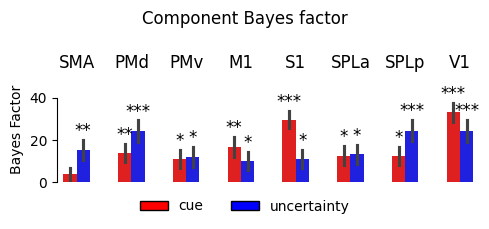

In [49]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

M = make_planning_models()
M, _ = find_model(M, 'component')
G = M.Gc
MF = pcm.model.ModelFamily(G, comp_names=['cue', 'uncertainty'], basecomponents=None)

fig, axs = plt.subplots(1, len(rois), figsize=(5, 2), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf', palette=['red', 'blue'],errorbar='se',width=1)

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0)

        mean = vals.mean()
        sem = vals.std(ddof=1) / (n**0.5)
        bar_height = mean + sem

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].spines[['left',]].set_bounds([0, 40])
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    if r == 0:
        axs[r].spines[['top', 'right','bottom',]].set_visible(False)
    else:
        axs[r].spines[['top', 'right','bottom','left']].set_visible(False)
        axs[r].tick_params(width=0)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')
    axs[r].set_title(roi)

for r in range(len(rois)):
    # axs[r].set_yscale('symlog')
    axs[r].set_ylim([0, 50])
    axs[r].set_xlim([-1, 2])

fig.suptitle('Component Bayes factor')


# Define legend handles
legend_handles = [
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=2,
           fontsize=10)

fig.tight_layout()
plt.show()

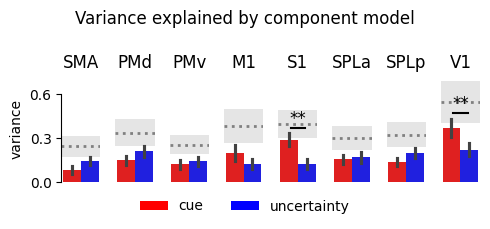

In [53]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['cue', 'uncertainty'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(5, 2),sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])
    tr_mean = np.sqrt(tr.mean())
    tr_err = np.sqrt(tr.std()) / np.sqrt(len(tr))

    # Bottom row: bar plot
    ax = axs[r]
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)

    df = pd.DataFrame(theta_sqrt.T, columns=features)

    sns.barplot(data=df, ax=ax, palette=['red', 'blue'], errorbar='se', width=1)
    ax.set_xticks([])
    ax.axhline(tr_mean, color='grey', lw=2, ls=':')
    ax.axhspan(tr_mean - tr_err,
                   tr_mean + tr_err, color='grey', alpha=.2, lw=0)
    ax.set_title(roi)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    # ax.set_xlim((-1, 2))
    ax.set_ylabel('variance')
    ax.set_yticks((0, .3, .6))
    ax.spines[['left',]].set_bounds(0, .6)
    if r > 0:
        ax.spines[['top', 'right','bottom','left']].set_visible(False)
        ax.tick_params(width=0)

    a = df['cue']
    b = df['uncertainty']

    _, p_val_paired = ttest_rel(a, b)

    # Significance stars
    if p_val_paired < 0.001:
        stars = '***'
    elif p_val_paired < 0.01:
        stars = '**'
    elif p_val_paired < 0.05:
        stars = '*'
    else:
        stars = None

    if stars:
        # Estimate max height for the bar
        y_max = np.max((a.mean() + a.std() / np.sqrt(len(a)),(b.mean() + b.std() / np.sqrt(len(b)))))

        # Compute x positions of the bars for the two models
        center = .5
        x1 = center - .4   # component
        x2 = center + .4   # feature

        # Draw bar and stars
        ax.plot([x1, x2], [y_max + .1 * y_max, y_max+ .1 * y_max], lw=1.5, c='k')
        ax.text(.5, y_max + .1 * y_max, stars, ha='center', va='bottom', fontsize=12)

fig.suptitle('Variance explained by component model')

# Define legend handles
legend_handles = [
    Patch(facecolor='red', edgecolor=None, label='cue'),
    Patch(facecolor='blue', edgecolor=None, label='uncertainty')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=2,
           fontsize=10)

fig.tight_layout()
plt.show()

Force dissimilarity against 0: TtestResult(statistic=np.float64(3.2106057951069467), pvalue=np.float64(0.006826772009600081), df=np.int64(13))


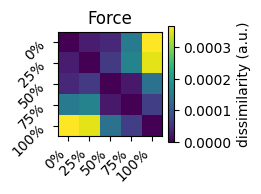

In [80]:
experiment = 'smp2'

fig, ax = plt.subplots(figsize=(1.5, 1.5))

vmin, vmax = -.0001, .0005

G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'G_obs.force.plan.npy'))
D_obs = pcm.G_to_dist(G_obs.mean(axis=0))

D = np.zeros(G_obs.shape[0])
for g, G in enumerate(G_obs):
    mask = np.tri(G.shape[0], k=-1, dtype=bool)
    D[g] = pcm.G_to_dist(G)[mask].mean()

print(f'Force dissimilarity against 0: {ttest_1samp(D, 0)}')

cond = list(gl.regressor_mapping.keys())[:5]

cax = ax.imshow(D_obs,)# vmin=vmin, vmax=vmax)

ax.set_xticks(np.arange(len(cond)))
ax.set_yticks(np.arange(len(cond)))
ax.set_xticklabels(cond, rotation=45, ha='right')
ax.set_yticklabels(cond, rotation=45, ha='right')

ax.set_title(f'Force')

cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.05)
cbar.set_label('dissimilarity (a.u.)')

plt.show()


Bayes against 0: TtestResult(statistic=np.float64(2.4601259124512227), pvalue=np.float64(0.028662183186994355), df=np.int64(13))
Bayes factor is 0.9309515164432036 of noise ceiling


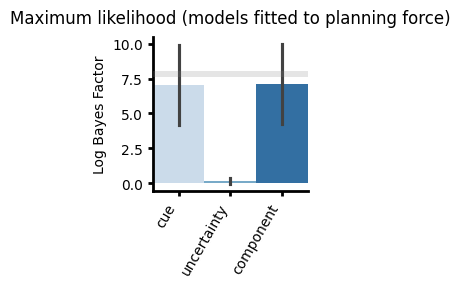

In [99]:
experiment = 'smp2'

T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.force.plan.p'))
T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.force.plan.p'))

Bayes_cue = T_cv.likelihood['cue'] - T_cv.likelihood['null']
Bayes_noise = T_cv.likelihood['ceil'] - T_cv.likelihood['null']
print(f'Bayes against 0: {ttest_1samp(Bayes_cue, 0)}')
print(f'Bayes factor is {Bayes_cue.mean() / Bayes_noise.mean()} of noise ceiling')

# Plotting
fig, ax = plt.subplots(figsize=(2, 2))

plt.sca(ax)
ax = pcm.model_plot(T_cv.likelihood,
                null_model = 'null',
                noise_ceiling= 'ceil',
                upper_ceiling = T_gr.likelihood['ceil'],
                width=1,
                palette='Blues',
                errorbar='se')
ax.set_xlabel('')
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

ax.set_ylabel('Log Bayes Factor')
ax.set_xlabel('')
ax.set_title('Maximum likelihood (models fitted to planning force)', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(2)
ax.tick_params(width=2)

plt.show()

Intercept not significant
Intercept is significantly > 0 (one-sided, p < 0.05), t=2.975496490091973, p=0.0057911394480142375


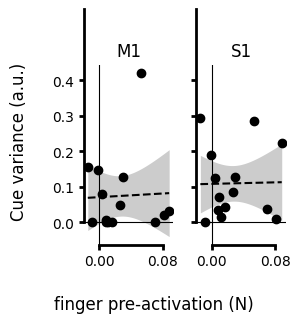

In [12]:
rois = ['M1', 'S1', ]
Hem = 'L'
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
experiment = 'smp2'
glm = 12

features = np.array(['cue', 'uncertainty'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

df = pd.DataFrame()
diff1, diff2, diff3 = np.zeros(len(snS)), np.zeros(len(snS)), np.zeros(len(snS))
for s, sn in enumerate(snS):
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df, df_tmp])
    diff1[s] = (df[df['cue'] == 39]['index0'].mean() - df[df['cue'] == 93]['index0'].mean() +
                df[df['cue'] == 93]['ring0'].mean() - df[df['cue'] == 39]['ring0'].mean()) / 2
    diff3[s] = (df[df['stimFinger'] == 91999]['index1'].mean() - df[df['stimFinger'] == 99919]['index1'].mean() +
                df[df['stimFinger'] == 99919]['ring1'].mean() - df[df['stimFinger'] == 91999]['ring1'].mean()) / 2
    diff2[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(3, 3.5))

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)

    # Regression for diff2
    x = diff2
    y = theta_exp[0]
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = slope * x_fit + intercept

    # Compute confidence intervals
    n = len(x)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    dof = n - 2
    t_val = t.ppf(0.95, dof)

    se_line = np.sqrt(np.sum(residuals**2) / dof * (1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2)))
    ci = t_val * se_line

    # Check confidence interval at x = 0
    ix_0 = np.argmin(np.abs(x_fit - 0))
    lower_bound = y_fit[ix_0] - ci[ix_0]
    upper_bound = y_fit[ix_0] + ci[ix_0]

    MSE = np.sum(residuals**2) / dof
    SE_intercept = np.sqrt(MSE * (1/n + np.mean(x)**2 / np.sum((x - np.mean(x))**2)))
    t_intercept = intercept / SE_intercept
    p = 1 - t.cdf(t_intercept, df=dof)

    if lower_bound > 0:
        print(f"Intercept is significantly > 0 (one-sided, p < 0.05), t={t_intercept}, p={p}")
    else:
        print(f'Intercept not significant')

    axs[r].plot(x_fit, y_fit, color='k', linestyle='--', label='Fit')
    axs[r].fill_between(x_fit, y_fit - ci, y_fit + ci, color='k', alpha=.2, label='95% CI', lw=0)
    axs[r].scatter(x, y, color='k')

    axs[r].axvline(0, lw=.8, color='k')
    axs[r].axhline(0, lw=.8, color='k')

    axs[r].set_title(roi)

    # Remove spines from 'left', 'top', and 'right'
    axs[r].spines['left'].set_bounds(0, .6)
    axs[r].spines['bottom'].set_bounds(0.0, .08)
    axs[r].spines['top'].set_visible(False)
    axs[r].spines['right'].set_visible(False)

    # Set ticks for x-axis and y-axis
    axs[r].set_xticks(np.linspace(0, .08, 2))
    axs[r].tick_params(width=2)

    # Set linewidth for remaining spines ('bottom') and ticks
    axs[r].spines['bottom'].set_linewidth(2)
    axs[r].spines['left'].set_linewidth(2)

fig.supxlabel('finger pre-activation (N)')
fig.supylabel('Cue variance (a.u.)')

fig.tight_layout()


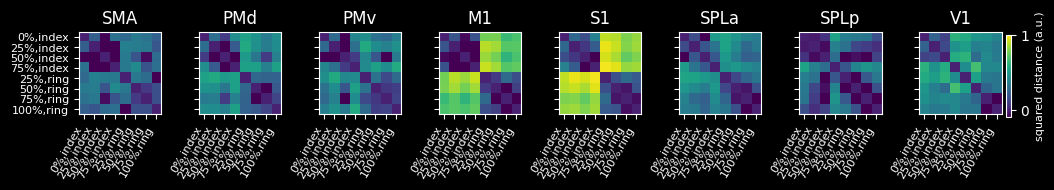

In [62]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

vmin, vmax = -.1, 1

fig, axs = plt.subplots(1, len(rois), figsize=(10, 6), sharey=True, sharex=True, constrained_layout=True)

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    G_obs_avg = G_obs.mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs_avg)
    D_obs = np.sign(D_obs) * np.sqrt(np.abs(D_obs))

    # Top row: imshow
    im_ax = axs[r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax, cmap='viridis')
    im_ax.set_xticks(np.arange(8))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    im_ax.set_yticks(np.arange(8))
    im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)

bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('squared distance (a.u.)', fontsize=8)


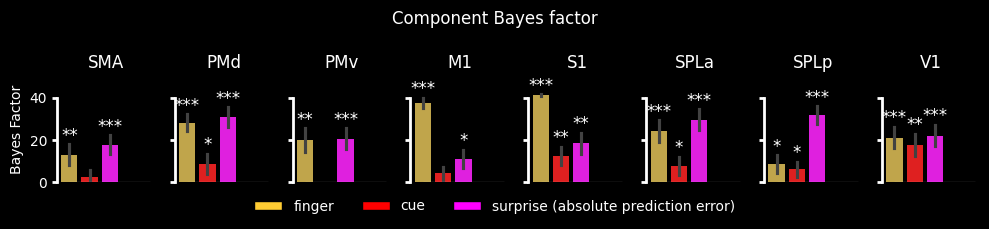

In [63]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

components = ['finger', 'cue', 'surprise']

M = make_execution_models()
M, _ = find_model(M, 'feature')
MF = pcm.model.ModelFamily(M, comp_names=components,)

fig, axs = plt.subplots(1, len(rois), figsize=(10, 2),  constrained_layout=True, sharey=True)

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf',palette=['#D4AF37', 'red', 'magenta'], errorbar='se')

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0, alternative='greater')

        mean = vals.mean()
        sem = vals.std() / np.sqrt(len(vals))
        bar_height = mean + sem

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].set_title(roi)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(components, rotation=60, ha='right')
    axs[r].hlines(0, 0, 4, color='w', lw=0.8)
    axs[r].spines[['top', 'right', 'bottom']].set_visible(False)
    axs[r].spines[['left', ]].set_bounds(0, 40)
    axs[r].spines[['left', ]].set_linewidth(2)
    axs[r].set_ylim([0, 50])
    axs[r].spines[['bottom',]].set_bounds(0, 5)
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    axs[r].tick_params(width=2)

# Define legend handles
legend_handles = [
    Patch(facecolor='#FFCC33', edgecolor='black', label='finger'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (absolute prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=6,
           fontsize=10)

fig.suptitle('Component Bayes factor')

fig.tight_layout()

plt.show()

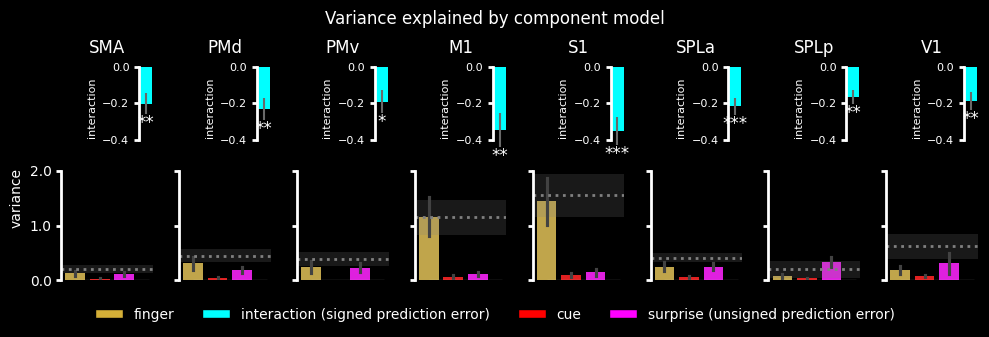

In [64]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

components = np.array(['finger', 'cue', 'surprise'])

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'component')
n_param_c = Mc.n_param

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'feature')
n_param_f = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(10, 3), sharey=True, constrained_layout=True)

inset_axs = []

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])

    ax = axs[r]
    params = pickle.load(f)

    # variance explained
    params_c = params[idxc]
    theta_c = params_c[:n_param_c]
    var_expl = np.exp(theta_c)

    # interaction
    params_f = params[idxf]
    theta_f = params_f[:n_param_f]
    interaction = theta_f[1, :] * theta_f[2, :]

    # main axes
    sns.barplot(data=var_expl.T, ax=ax, palette=['#D4AF37', 'red', 'magenta'], errorbar='se')
    ax.set_title(roi, pad=10)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(components, rotation=60, ha='right')
    ax.hlines(0, 0, 3, color='w', lw=0.8)
    ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
    ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.spines[['left', ]].set_bounds(0, 2)
    ax.spines[['left', ]].set_linewidth(2)
    ax.set_yticks([-.5, 0, 1, 2])
    ax.set_ylim((0, 3))
    ax.spines[['bottom',]].set_bounds(0, 4)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.set_ylabel('variance')
    ax.tick_params(width=2)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    # inset for interaction
    inset_ax = ax.inset_axes([.85, .8, .15, .5], transform=ax.transAxes)
    interaction = theta_f[1,:] * theta_f[2,:]
    inset_ax.bar(0, interaction.mean(), width=.5, facecolor='cyan', yerr=interaction.std() / np.sqrt(len(interaction)), ecolor='dimgrey')
    inset_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    inset_ax.spines[['left', ]].set_linewidth(2)
    inset_ax.spines[['left', ]].set_bounds(-.4, 0)
    inset_ax.set_ylabel('interaction', fontsize=8)
    inset_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    inset_ax.tick_params(axis='y', width=2, labelsize=8)
    inset_ax.set_ylim(-.45, 0)

    # t-test against zero for interaction
    _, p_val_1samp = ttest_1samp(interaction, 0, alternative='two-sided')

    n = len(interaction)
    mean = np.abs(interaction.mean())
    sem = interaction.std() / np.sqrt(len(interaction))
    bar_height = np.sign(interaction.mean()) * (mean + sem) * 1

    if p_val_1samp < 0.001:
        stars = '***'
    elif p_val_1samp < 0.01:
        stars = '**'
    elif p_val_1samp < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    if stars:
        inset_ax.text(0, bar_height, stars, ha='center', va='top', fontsize=12)

    inset_axs.append(inset_ax)

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction (signed prediction error)'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (unsigned prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=6,
           fontsize=10)

fig.tight_layout()

fig.suptitle('Variance explained by component model')


plt.show()

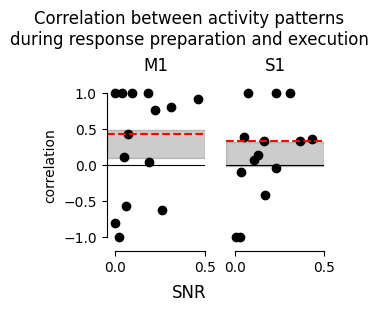

In [10]:
f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)[-1]

rois = ['M1', 'S1']

fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(3, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]

    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.glm{glm}.{H}.{roi}.p'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[-1]

    N = theta.shape[1]

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[-1]

    sigma2_1 = np.exp(theta[0])
    sigma2_2 = np.exp(theta[1])
    r_indiv = Mflex.get_correlation(theta)
    sigma2_e = np.exp(theta[3])
    SNR = np.sqrt(sigma2_1*sigma2_2)/sigma2_e
    ax.scatter(SNR, r_indiv, color='k')

    theta_g,_= pcm.group_to_individ_param(theta_g,Mflex,N)
    r_group = Mflex.get_correlation(theta_g)
    ax.axhline(r_group[0], color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.set_title(roi)

    ax.axhspan(r_indiv.mean() - (r_indiv.std() / np.sqrt(r_indiv.size)),
               r_indiv.mean() + (r_indiv.std() / np.sqrt(r_indiv.size)), alpha=.2, color='k')

    ax.set_ylim(-1.2, 1.2)
    ax.set_xlim(-.05, .5)

    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines[['bottom']].set_bounds(0, .5)
    ax.spines[['left']].set_bounds(-1, 1)

    if r==0:
        ax.spines[['left']].set_visible(True)
    else:
        ax.set_yticks([])

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between activity patterns\nduring response preparation and execution')

plt.show()


Text(0.02, 0.5, 'log-likelihood')

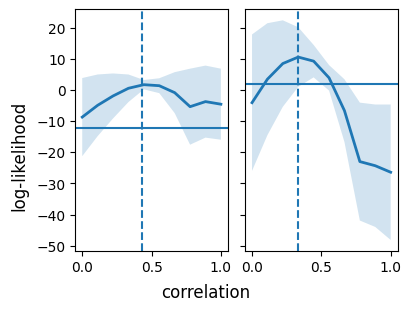

In [12]:
f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan-exec.p'), "rb")
M = pickle.load(f)
nsteps = len(M) - 1

fig, axs = plt.subplots(1, len(rois),figsize=(4, 3), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]

    # load log-likelihoods
    T_in = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.glm{glm}.{H}.{roi}.p'))

    # load params
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_in = pickle.load(f)

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[-1]

    N = theta_in[0].shape[1] # N participants

    L = T_in.likelihood.to_numpy()
    L = L - L.mean(axis=1).reshape(-1, 1)
    maxL = L[:,-1]
    L = L[:,0:-1] # Remove flexible model

    L_avg = L.mean(axis=0)
    L_err = L.std(axis=0) / np.sqrt(N)

    maxL_cv = np.empty(N)
    for n in range(N):
        mask = np.delete(np.arange(N), n)
        peak_ind = np.argmax(L[mask, :].mean(axis=0))  # Find best model on N-1 subjects
        maxL_cv[n] = L[n, peak_ind]  # Log-likelihood of that model on left-out subject

    r, tval, pval = (np.empty(nsteps) for _ in range(3))
    for i in range(nsteps):
        r[i] = M[i].corr
        tval[i], pval[i] = ttest_rel(maxL_cv, L[:, i], alternative='greater')

    theta_g,_= pcm.group_to_individ_param(theta_g,M[-1],N)
    maxr = M[-1].get_correlation(theta_g)

    tval0, pval0 = ttest_rel(maxL, L[:, 0], alternative='greater')

    ax.plot(r, L_avg,  lw=2)
    ax.fill_between(r, L_avg - L_err, L_avg + L_err, lw=0, alpha=.2)

    x = np.where(pval < .05)[0]
    if x.size > 0:
        ax.axvspan(r[x[0]], r[x[-1]], color='k', alpha=0.2, lw=0)
    ax.axhline(maxL_cv.mean())
    ax.axvline(maxr.mean(),  ls='--')


fig.supxlabel('correlation')
fig.supylabel('log-likelihood')